#Generate creative artwork using Stable Diffusion.

Step 1: Install the Deep Learning Libraries

In [1]:
!pip install -q diffusers transformers accelerate

Step 2: Build the Stable Diffusion Generator

In [2]:
import torch
from diffusers import StableDiffusionXLPipeline
from IPython.display import display

print("Loading Stable Diffusion XL... (This may take a few minutes to download)")

# 1. Load the SDXL pipeline
# We use float16 precision and safetensors to make it fit in the Colab GPU
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
)

# 2. VRAM Management
# SDXL is huge. This command dynamically moves parts of the model between your
# CPU and GPU so it doesn't crash the free Colab tier.
pipe.enable_model_cpu_offload()

print("Model loaded! Ready to generate art.")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading Stable Diffusion XL... (This may take a few minutes to download)


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Model loaded! Ready to generate art.


Step 3: Generate the Creative Artwork

Generating artwork for: 'A breathtaking surreal digital painting of a glowing futuristic city built on the branches of a giant cosmic tree, deep space nebula in the background, waterfalls of stardust, highly detailed, vivid colors, cinematic lighting, 8k resolution, trending on ArtStation'...
The GPU is running the diffusion loop. This will take about 30-45 seconds...


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


✅ Masterpiece created!


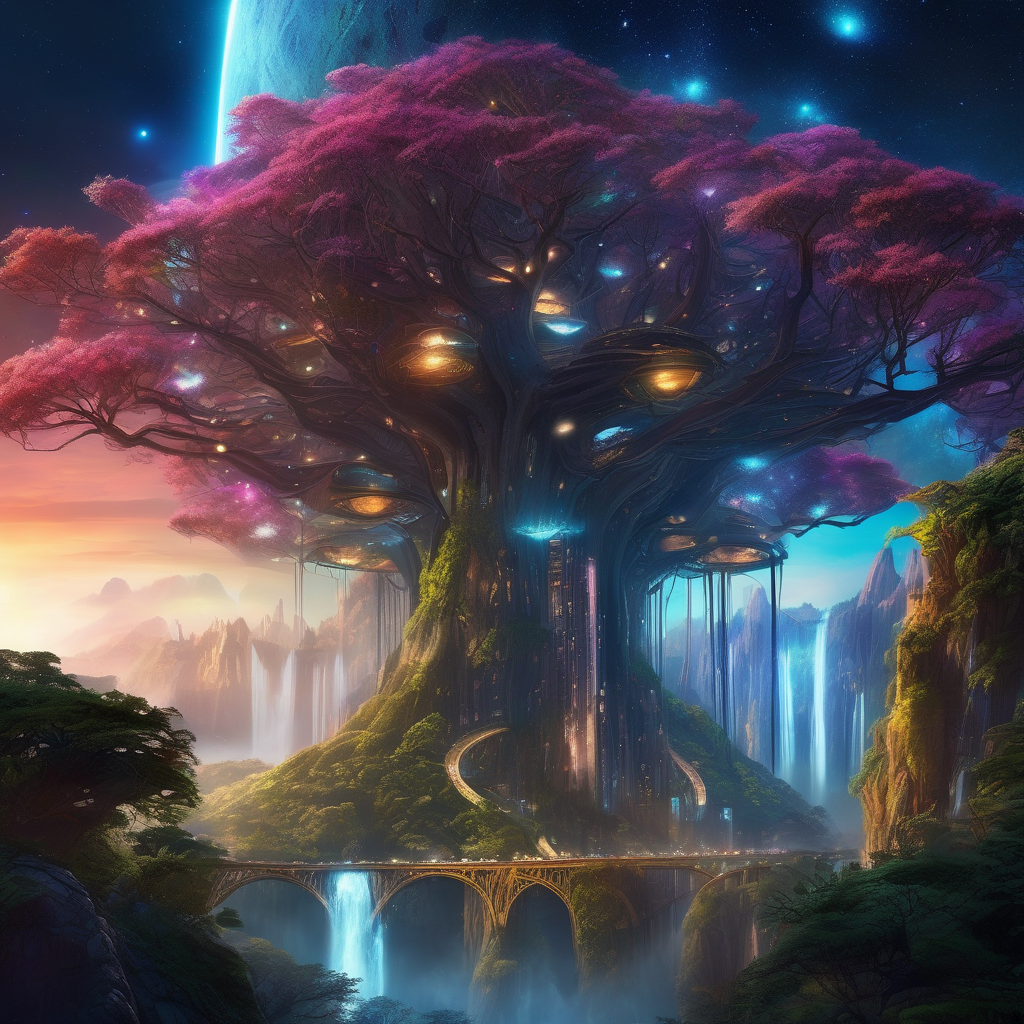

In [3]:
# 1. Define your creative vision
prompt = (
    "A breathtaking surreal digital painting of a glowing futuristic city "
    "built on the branches of a giant cosmic tree, deep space nebula in the background, "
    "waterfalls of stardust, highly detailed, vivid colors, cinematic lighting, 8k resolution, trending on ArtStation"
)

# 2. Tell the AI what you DO NOT want to see (Crucial for high quality)
negative_prompt = (
    "blurry, pixelated, low quality, distorted, watermark, text, signature, bad anatomy, dull colors"
)

print(f"Generating artwork for: '{prompt}'...")
print("The GPU is running the diffusion loop. This will take about 30-45 seconds...")

# 3. Generate the image
# num_inference_steps: Higher = more detailed (but slower)
# guidance_scale: How strictly the AI follows your prompt (7.0 to 9.0 is the sweet spot)
image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=40,
    guidance_scale=7.5
).images[0]

# 4. Save and display
output_filename = "ai_creative_artwork.png"
image.save(output_filename)

print("✅ Masterpiece created!")
display(image)